In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/raw/cardio_train.csv", sep=";")

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 70000
Columns: 13


In [8]:
print(df.columns.tolist())

['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


In [9]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 2. Dataset Understanding

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [11]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
print(df.isnull().sum())

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [14]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
df["age_years"] = df["age"] / 365.25

In [16]:
print(df["age_years"].describe())

count    70000.000000
mean        53.302850
std          6.754967
min         29.563313
25%         48.361396
50%         53.943874
75%         58.390144
max         64.922656
Name: age_years, dtype: float64


In [17]:
print("Minimum age:", df["age_years"].min())
print("Maximum age:", df["age_years"].max())

Minimum age: 29.56331279945243
Maximum age: 64.92265571526352


In [18]:
print("Invalid systolic BP values:", (df["ap_hi"] <= 0).sum())
print("Invalid diastolic BP values:", (df["ap_lo"] <= 0).sum())

Invalid systolic BP values: 7
Invalid diastolic BP values: 22


In [19]:
bp_invalid = df[(df["ap_hi"] <= 0) | (df["ap_lo"] <= 0)]

print("Number of rows with non-positive BP:", len(bp_invalid))
bp_invalid[["age", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]].head(20)

Number of rows with non-positive BP: 29


,age,gender,height,weight,ap_hi,ap_lo,cardio
2014,22712,2,167,59.0,906,0,0
4607,15281,1,165,78.0,-100,80,0
13489,14965,2,150,60.0,130,0,0
16021,22108,2,161,90.0,-115,70,0
16459,20457,1,156,50.0,138,0,1
17381,18226,1,164,78.0,138,0,0
20536,15581,1,153,54.0,-100,70,0
22923,21182,2,166,68.0,149,0,1
23867,16131,1,161,92.0,906,0,1
23988,18301,1,162,74.0,-140,90,1


In [20]:
bp_order_error = df[df["ap_hi"] <= df["ap_lo"]]

print("Rows where systolic BP <= diastolic BP:", len(bp_order_error))

Rows where systolic BP <= diastolic BP: 1236


In [21]:
df["age_years"] = df["age"] / 365.25

In [22]:
bp_order_error = df[df["ap_hi"] <= df["ap_lo"]]

print("Number of rows:", len(bp_order_error))

bp_order_error[[
    "age",
    "gender",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cardio"
]].head(30)

Number of rows: 1236


,age,gender,height,weight,ap_hi,ap_lo,cardio
228,17489,2,183,98.0,160,1100,1
241,21932,2,157,60.0,160,1000,1
260,18217,1,150,83.0,140,800,1
329,23407,1,176,63.0,160,1000,1
345,18704,1,154,81.0,140,1000,1
473,15226,1,150,95.0,150,1033,1
474,19099,1,156,65.0,120,150,0
559,20430,2,173,101.0,200,1000,1
567,21281,1,168,78.0,14,90,1
613,18963,1,165,92.0,140,1000,1


In [23]:
print(bp_order_error[["ap_hi", "ap_lo"]].value_counts().head(20))

ap_hi  ap_lo
150    1000     197
160    1000     169
140    1000     141
12     80        67
180    1000      47
160    1100      46
170    1000      42
150    1100      31
130    1000      28
180    1100      28
80     120       24
140    1100      19
190    1000      17
14     90        16
170    1100      15
11     70        14
90     140        9
120    1000       8
90     130        8
70     110        7
Name: count, dtype: int64


In [24]:
print("Lowest systolic values:")
print(df["ap_hi"].nsmallest(20).to_list())

Lowest systolic values:
[-150, -140, -120, -120, -115, -100, -100, 1, 1, 7, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11]


In [25]:
print("\nHighest systolic values:")
print(df["ap_hi"].nlargest(20).to_list())


Highest systolic values:
[16020, 14020, 14020, 14020, 14020, 13010, 13010, 11500, 11020, 2000, 1620, 1500, 1420, 1420, 1409, 1400, 1400, 1400, 1300, 1300]


In [26]:
print("Lowest diastolic values:")
print(df["ap_lo"].nsmallest(20).to_list())

Lowest diastolic values:
[-70, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [27]:
print("\nHighest diastolic values:")
print(df["ap_lo"].nlargest(20).to_list())


Highest diastolic values:
[11000, 10000, 10000, 10000, 9800, 9100, 9011, 9011, 8500, 8200, 8100, 8099, 8099, 8099, 8079, 8077, 8044, 8000, 8000, 7100]


In [28]:
for col in ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]:
    print("\n" + "="*30)
    print(col)
    print(df[col].value_counts().sort_index())


gender
gender
1    45530
2    24470
Name: count, dtype: int64

cholesterol
cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

gluc
gluc
1    59479
2     5190
3     5331
Name: count, dtype: int64

smoke
smoke
0    63831
1     6169
Name: count, dtype: int64

alco
alco
0    66236
1     3764
Name: count, dtype: int64

active
active
0    13739
1    56261
Name: count, dtype: int64

cardio
cardio
0    35021
1    34979
Name: count, dtype: int64


In [29]:
print("gender:", sorted(df["gender"].unique()))
print("cholesterol:", sorted(df["cholesterol"].unique()))
print("gluc:", sorted(df["gluc"].unique()))
print("smoke:", sorted(df["smoke"].unique()))
print("alco:", sorted(df["alco"].unique()))
print("active:", sorted(df["active"].unique()))
print("cardio:", sorted(df["cardio"].unique()))

gender: [np.int64(1), np.int64(2)]
cholesterol: [np.int64(1), np.int64(2), np.int64(3)]
gluc: [np.int64(1), np.int64(2), np.int64(3)]
smoke: [np.int64(0), np.int64(1)]
alco: [np.int64(0), np.int64(1)]
active: [np.int64(0), np.int64(1)]
cardio: [np.int64(0), np.int64(1)]


In [30]:
print("Cardio counts:")
print(df["cardio"].value_counts())

Cardio counts:
cardio
0    35021
1    34979
Name: count, dtype: int64


In [31]:
print("\nCardio percentages:")
print(df["cardio"].value_counts(normalize=True) * 100)


Cardio percentages:
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


## 3. Blood Pressure Data Quality Analysis

In [32]:
print("Systolic BP below 70:", (df["ap_hi"] < 70).sum())
print("Systolic BP above 250:", (df["ap_hi"] > 250).sum())

print("Diastolic BP below 40:", (df["ap_lo"] < 40).sum())
print("Diastolic BP above 150:", (df["ap_lo"] > 150).sum())

Systolic BP below 70: 189
Systolic BP above 250: 40
Diastolic BP below 40: 59
Diastolic BP above 150: 975


In [33]:
non_positive_bp = (
    (df["ap_hi"] <= 0) |
    (df["ap_lo"] <= 0)
)

bp_order_issue = df["ap_hi"] <= df["ap_lo"]

print("Non-positive BP rows:", non_positive_bp.sum())
print("Systolic <= Diastolic rows:", bp_order_issue.sum())


Non-positive BP rows: 29
Systolic <= Diastolic rows: 1236


In [34]:
extreme_bp = (
    (df["ap_hi"] < 70) |
    (df["ap_hi"] > 250) |
    (df["ap_lo"] < 40) |
    (df["ap_lo"] > 150)
)

print("Rows with extreme BP values:", extreme_bp.sum())

Rows with extreme BP values: 1246


In [35]:
extreme_bp_rows = df[extreme_bp]

extreme_bp_rows[
    ["age", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]
].head(30)

,age,gender,height,weight,ap_hi,ap_lo,cardio
228,17489,2,183,98.0,160,1100,1
241,21932,2,157,60.0,160,1000,1
260,18217,1,150,83.0,140,800,1
329,23407,1,176,63.0,160,1000,1
345,18704,1,154,81.0,140,1000,1
418,16658,1,157,72.0,150,30,1
473,15226,1,150,95.0,150,1033,1
559,20430,2,173,101.0,200,1000,1
567,21281,1,168,78.0,14,90,1
613,18963,1,165,92.0,140,1000,1


In [36]:
print(
    extreme_bp_rows[["ap_hi", "ap_lo"]]
    .value_counts()
    .head(30)
)

ap_hi  ap_lo
150    1000     197
160    1000     169
140    1000     141
12     80        67
180    1000      47
160    1100      46
170    1000      42
150    1100      31
130    1000      28
180    1100      28
140    1100      19
190    1000      17
14     90        16
170    1100      15
11     70        14
120    1000       8
14     80         7
15     90         7
160    1200       7
13     90         7
11     80         6
180    1200       6
200    1000       5
120    20         5
11     60         4
906    0          4
12     70         4
120    30         4
200    1200       4
110    20         4
Name: count, dtype: int64


In [37]:
valid_bp_candidate = df[~extreme_bp]

order_issue_clean_range = (
    valid_bp_candidate["ap_hi"] <= valid_bp_candidate["ap_lo"]
)

print(
    "Rows with systolic <= diastolic after removing extreme BP candidates:",
    order_issue_clean_range.sum()
)

Rows with systolic <= diastolic after removing extreme BP candidates: 88


In [38]:
print("Height below 120:", (df["height"] < 120).sum())
print("Height above 220:", (df["height"] > 220).sum())

print("Weight below 30:", (df["weight"] < 30).sum())
print("Weight above 200:", (df["weight"] > 200).sum())

Height below 120: 52
Height above 220: 1
Weight below 30: 7
Weight above 200: 0


In [39]:
print("Smallest heights:", df["height"].nsmallest(15).to_list())
print("Largest heights:", df["height"].nlargest(15).to_list())

print("Smallest weights:", df["weight"].nsmallest(15).to_list())
print("Largest weights:", df["weight"].nlargest(15).to_list())

Smallest heights: [55, 57, 59, 60, 64, 65, 65, 66, 67, 67, 67, 68, 68, 70, 70]
Largest heights: [250, 207, 200, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198]
Smallest weights: [10.0, 11.0, 21.0, 22.0, 23.0, 28.0, 29.0, 30.0, 30.0, 30.0, 31.0, 32.0, 32.0, 32.0, 33.0]
Largest weights: [200.0, 200.0, 183.0, 181.0, 180.0, 180.0, 180.0, 180.0, 178.0, 178.0, 178.0, 177.0, 175.0, 172.0, 171.0]


In [40]:
bp_order_issue_remaining = valid_bp_candidate[
    valid_bp_candidate["ap_hi"] <= valid_bp_candidate["ap_lo"]
]

print("Rows:", len(bp_order_issue_remaining))

bp_order_issue_remaining[
    ["age", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]
].head(50)

Rows: 88


,age,gender,height,weight,ap_hi,ap_lo,cardio
474,19099,1,156,65.0,120,150,0
636,20457,2,169,68.0,70,110,0
2384,23361,1,154,102.0,90,150,1
2990,21957,2,182,90.0,80,140,1
3447,19992,2,180,80.0,80,125,1
3623,21874,1,160,83.0,80,120,0
4825,19618,2,164,89.0,90,140,1
4830,16969,2,159,68.0,70,100,0
5121,17600,2,173,78.0,90,140,1
5446,18968,1,165,110.0,95,130,1


In [41]:
print(
    bp_order_issue_remaining[["ap_hi", "ap_lo"]]
    .value_counts()
    .head(30)
)

ap_hi  ap_lo
80     120      24
90     140       9
       130       8
70     110       7
80     130       6
       140       5
90     150       4
80     110       4
70     120       3
       100       2
95     140       2
100    100       2
120    150       1
80     125       1
95     130       1
85     95        1
95     100       1
100    150       1
90     100       1
85     130       1
80     100       1
90     120       1
80     105       1
95     135       1
Name: count, dtype: int64


In [42]:
height_weight_issue = df[
    (df["height"] < 120) |
    (df["height"] > 220) |
    (df["weight"] < 30)
]

print("Height/weight issue rows:", len(height_weight_issue))

height_weight_issue[
    ["age", "gender", "height", "weight", "ap_hi", "ap_lo", "cardio"]
].sort_values("height").head(30)

Height/weight issue rows: 60


,age,gender,height,weight,ap_hi,ap_lo,cardio
22723,23386,1,55,81.0,130,90,1
66643,18830,1,57,61.0,130,90,1
64115,18426,1,59,57.6,125,67,0
29157,19088,1,60,69.0,110,70,0
27603,20978,1,64,61.0,130,70,0
44490,19120,1,65,60.0,120,80,0
33607,19709,2,65,72.0,130,80,0
64454,21348,1,66,63.0,12,80,1
14323,22005,1,67,57.0,120,90,1
53344,20541,2,67,80.0,120,80,1


In [43]:
print("Height issue rows:", ((df["height"] < 120) | (df["height"] > 220)).sum())
print("Weight issue rows:", (df["weight"] < 30).sum())

Height issue rows: 53
Weight issue rows: 7


In [44]:
clean_df = df.copy()

In [45]:
valid_data = (
    (clean_df["ap_hi"] >= 70) &
    (clean_df["ap_hi"] <= 240) &
    (clean_df["ap_lo"] >= 40) &
    (clean_df["ap_lo"] <= 160) &
    (clean_df["ap_hi"] > clean_df["ap_lo"]) &
    (clean_df["height"] >= 120) &
    (clean_df["height"] <= 207) &
    (clean_df["weight"] >= 30) &
    (clean_df["weight"] <= 200)
)

print("Valid rows:", valid_data.sum())
print("Rows to remove:", (~valid_data).sum())

Valid rows: 68612
Rows to remove: 1388


In [46]:
clean_df = clean_df[valid_data].copy()
clean_df = clean_df.reset_index(drop=True)

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

Original rows: 70000
Cleaned rows: 68612
Rows removed: 1388


In [47]:
print("Systolic BP:", clean_df["ap_hi"].min(), "to", clean_df["ap_hi"].max())
print("Diastolic BP:", clean_df["ap_lo"].min(), "to", clean_df["ap_lo"].max())
print("Height:", clean_df["height"].min(), "to", clean_df["height"].max())
print("Weight:", clean_df["weight"].min(), "to", clean_df["weight"].max())

print(
    "Systolic <= Diastolic:",
    (clean_df["ap_hi"] <= clean_df["ap_lo"]).sum()
)

Systolic BP: 70 to 240
Diastolic BP: 40 to 160
Height: 120 to 207
Weight: 30.0 to 200.0
Systolic <= Diastolic: 0


In [48]:
clean_df["age_years"] = clean_df["age"] / 365.25

In [49]:
clean_df["age_years"].describe()

count    68612.000000
mean        53.291619
std          6.757029
min         29.563313
25%         48.344969
50%         53.941136
75%         58.382615
max         64.922656
Name: age_years, dtype: float64

In [51]:
clean_df.drop(columns=["age"], inplace=True)

In [52]:
clean_df.head()

,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205


In [53]:
clean_df["bmi"] = (
    clean_df["weight"] /
    (clean_df["height"] / 100) ** 2
)

In [54]:
clean_df[["height", "weight", "bmi"]].head()

,height,weight,bmi
0,168,62.0,21.967120
1,156,85.0,34.927679
2,165,64.0,23.507805
3,169,82.0,28.710479
4,156,56.0,23.011177


In [55]:
clean_df.drop(columns=["id"], inplace=True)

In [56]:
print(clean_df.columns)
print("Shape:", clean_df.shape)

Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi'],
      dtype='str')
Shape: (68612, 13)


In [57]:
clean_df.to_csv("../data/processed/cardio_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

Cleaned dataset saved successfully!
Rows: 68612
Columns: 13


In [58]:
import os

print(os.path.exists("../data/processed/cardio_cleaned.csv"))

True


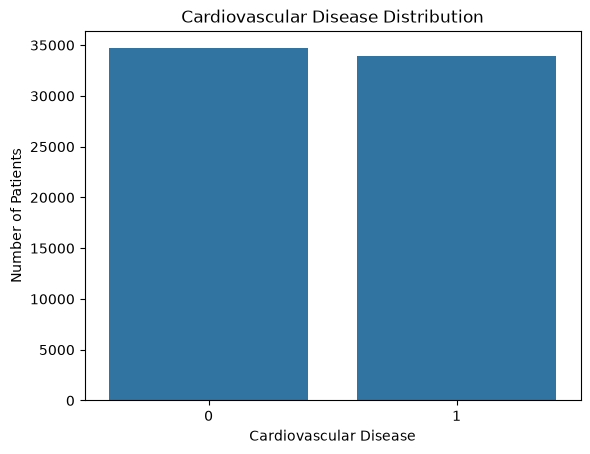

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=clean_df, x="cardio")

plt.title("Cardiovascular Disease Distribution")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Number of Patients")
plt.show()

In [60]:
print(clean_df["cardio"].value_counts())
print(clean_df["cardio"].value_counts(normalize=True) * 100)

cardio
0    34670
1    33942
Name: count, dtype: int64
cardio
0    50.530519
1    49.469481
Name: proportion, dtype: float64


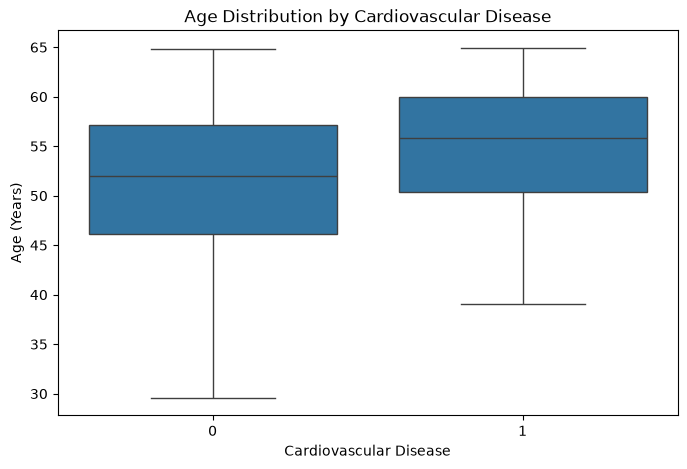

In [61]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_df,
    x="cardio",
    y="age_years"
)

plt.title("Age Distribution by Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Age (Years)")
plt.show()

In [62]:
print(
    clean_df.groupby("cardio")["age_years"]
    .agg(["mean", "median", "min", "max"])
)

             mean     median        min        max
cardio                                            
0       51.691108  52.032854  29.563313  64.826831
1       54.926459  55.819302  39.082820  64.922656


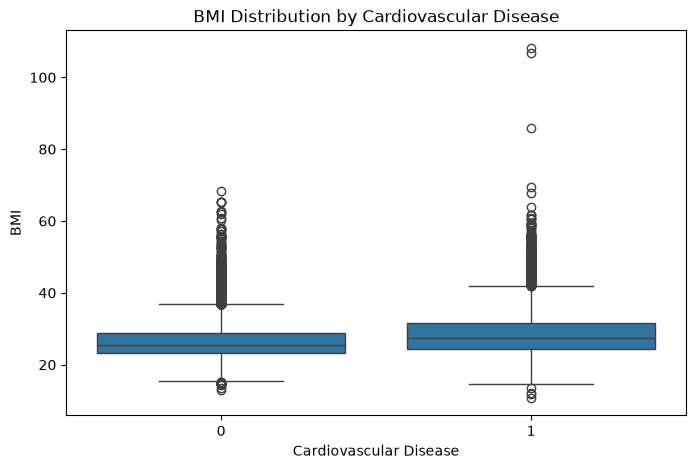

In [63]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_df,
    x="cardio",
    y="bmi"
)

plt.title("BMI Distribution by Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("BMI")
plt.show()

In [64]:
print(
    clean_df.groupby("cardio")["bmi"]
    .agg(["mean", "median", "min", "max"])
)

             mean     median        min         max
cardio                                             
0       26.471283  25.469388  12.855831   68.308315
1       28.464710  27.434842  10.726644  108.169847


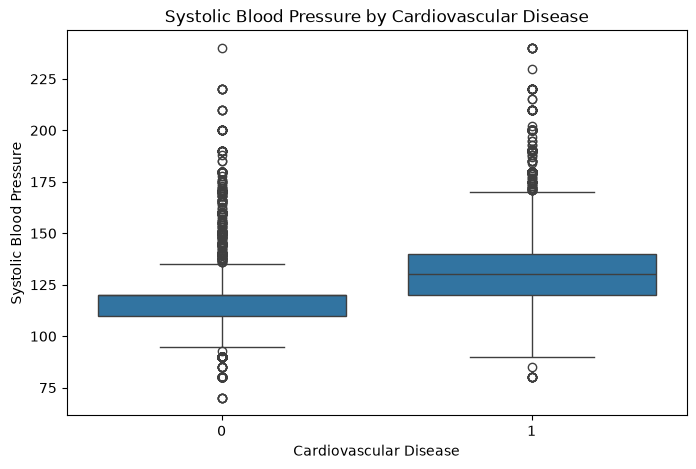

In [65]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_df,
    x="cardio",
    y="ap_hi"
)

plt.title("Systolic Blood Pressure by Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Systolic Blood Pressure")
plt.show()

In [66]:
print(
    clean_df.groupby("cardio")["ap_hi"]
    .agg(["mean", "median", "min", "max"])
)

              mean  median  min  max
cardio                              
0       119.606721   120.0   70  240
1       133.891344   130.0   80  240


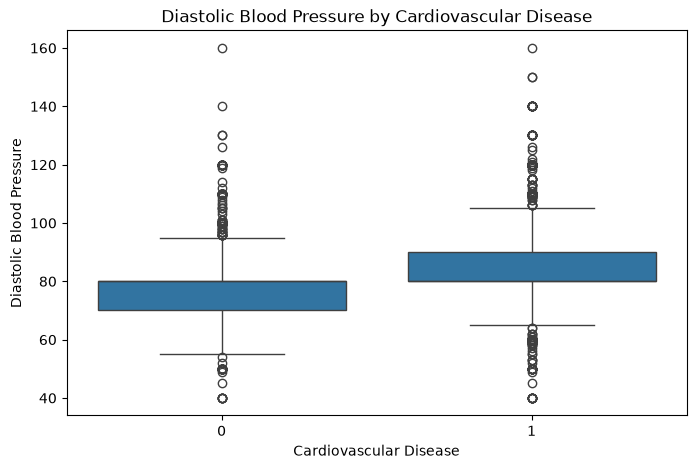

In [67]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_df,
    x="cardio",
    y="ap_lo"
)

plt.title("Diastolic Blood Pressure by Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Diastolic Blood Pressure")
plt.show()

In [68]:
print(
    clean_df.groupby("cardio")["ap_lo"]
    .agg(["mean", "median", "min", "max"])
)

             mean  median  min  max
cardio                             
0       78.126911    80.0   40  160
1       84.549555    80.0   40  160


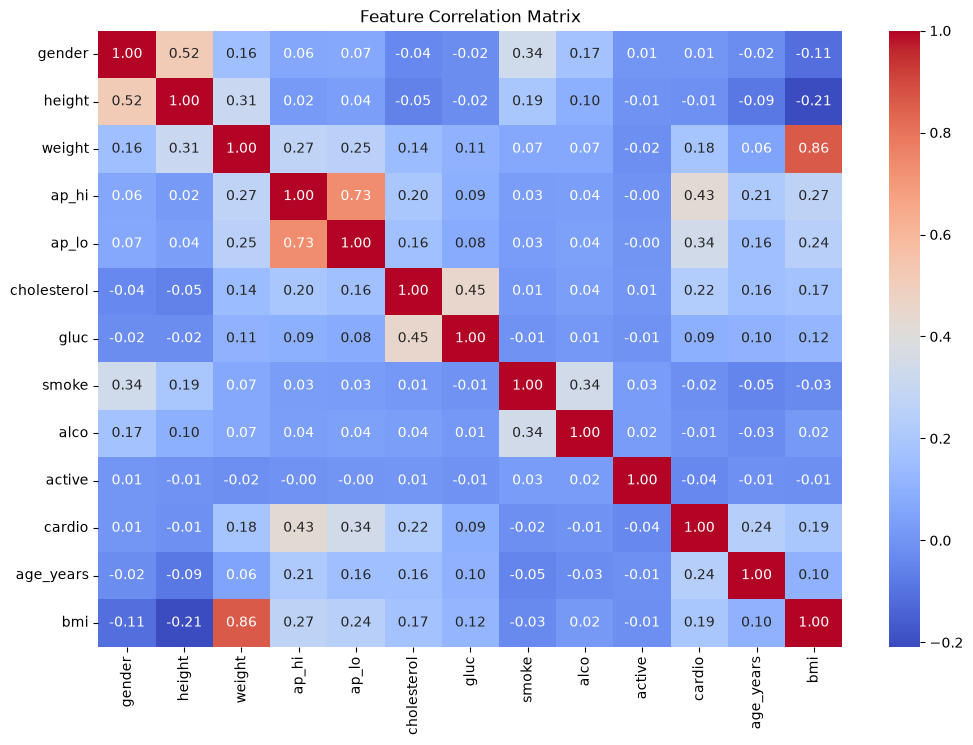

In [69]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    clean_df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [70]:
from sklearn.model_selection import train_test_split

# Features
X = clean_df.drop(columns=["cardio"])

# Target
y = clean_df["cardio"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (54889, 12)
X_test shape: (13723, 12)
y_train shape: (54889,)
y_test shape: (13723,)


In [71]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
cardio
0    50.531072
1    49.468928
Name: proportion, dtype: float64

Testing distribution:
cardio
0    50.52831
1    49.47169
Name: proportion, dtype: float64


In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

numerical_features = [
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "age_years",
    "bmi"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [73]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (54889, 14)
Processed X_test shape: (13723, 14)


In [74]:
print("Original features:", X_train.shape[1])
print("Processed features:", X_train_processed.shape[1])

Original features: 12
Processed features: 14


In [75]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

X_train_processed_df.to_csv(
    "../data/processed/X_train_processed.csv",
    index=False
)

X_test_processed_df.to_csv(
    "../data/processed/X_test_processed.csv",
    index=False
)

y_train.to_csv(
    "../data/processed/y_train.csv",
    index=False
)

y_test.to_csv(
    "../data/processed/y_test.csv",
    index=False
)

print("All processed datasets saved successfully!")

All processed datasets saved successfully!


In [76]:
import joblib

joblib.dump(
    preprocessor,
    "../data/processed/preprocessor.pkl"
)

print("Preprocessor saved successfully!")

Preprocessor saved successfully!
